In [1]:
# -*- coding: utf-8 -*-
'''计算数据的统计指标'''

import numpy as np
from numpy.core.fromnumeric import partition
from scipy.stats import pearsonr
import pandas as pd

MINVALID=1

In [2]:
def delete_missing(obs, mdl):
#	'''处理缺失值'''
    data = np.stack((obs, mdl))
    nanColumn = np.nonzero(np.isnan(data))
    return np.delete(data, nanColumn[1], axis=1)

def serail_r(obs, mdl):
#    ''' 计算相关系数 '''
    data = delete_missing(obs, mdl)
    if data.shape[1] < MINVALID:
        return np.nan, data.shape[1]
    return pearsonr(data[0, :], data[1, :])[0], data.shape[1]

def serail_rmse(obs, mdl):
#    ''' 计算rmse '''
    data = delete_missing(obs, mdl)
    if data.shape[1] < MINVALID:
        return np.nan, data.shape[1]
    return np.sqrt(((data[0, :]-data[1, :])**2).mean()), data.shape[1]

def serail_mb(obs, mdl):
#    ''' 计算偏差 '''
    data = delete_missing(obs, mdl)
    if data.shape[1] < MINVALID:
        return np.nan, data.shape[1]
    return np.mean(data[1] - data[0]), data.shape[1]


def serail_nmb(obs, mdl):
#    ''' 标准化平均偏差 '''
    data = delete_missing(obs, mdl)
    if data.shape[1] < MINVALID:
        return np.nan, data.shape[1]
    return np.sum((data[1] - data[0])/(np.sum(data[0])))*100, data.shape[1]

In [24]:
def main(modelName, obs_data1, model_data1,obs_data2, model_data2,obs_data3, model_data3):   
    
    #1. 读取数据
    obs1 = np.array(obs_data1)
    obs1[obs1==-999] = np.nan
    mdl1 = np.array(model_data1)

    obs2 = np.array(obs_data2)
    obs2[obs2==-999] = np.nan
    mdl2 = np.array(model_data2)

    obs3 = np.array(obs_data3)
    obs3[obs3==-999] = np.nan
    mdl3 = np.array(model_data3)

    obs = np.hstack((obs1, obs2,obs3))
    mdl = np.hstack((mdl1, mdl2,mdl3))

    #2. 数据统计指标的计算
    filtData = delete_missing(obs, mdl)
    R = serail_r(obs, mdl)
    RMSE = serail_rmse(obs, mdl)
    MB = serail_mb(obs, mdl)
    NMB = serail_nmb(obs, mdl)
    MO = (np.nanmean(filtData[0]),)
    MM = (np.nanmean(filtData[1]),)
    print(R, RMSE, MB, NMB, MO, MM)

    #3. 数据的绘图
    import matplotlib.pyplot as plt
    # plot
    fig, ax = plt.subplots(figsize=(5,5))  

    ax.scatter(obs2, mdl2, vmin=390, vmax=500, marker='o', c="red", edgecolors="black", linewidths=0.5,label='In Obspack')    
    ax.scatter(obs3, mdl3, vmin=390, vmax=500, marker='o', c="red", edgecolors="black", linewidths=0.5)    
    ax.scatter(obs1, mdl1, vmin=390, vmax=500, marker='^', c="blue", edgecolors="black", linewidths=0.5,label='Out of Obapack') 

    ax.set(xlim=(390, 460), xticks=np.arange(390, 460, 10),
           ylim=(390, 460), yticks=np.arange(390, 460, 10))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    x = np.linspace(0, 1000, 100)
    ax.plot(x, x, linestyle='--', color='red') 

    ax.grid(True)    
    indexdata = [MO,MM,MB,NMB,RMSE,R]
    string_ = ['MO','MM','MB','NMB','RMSE','R']
    unitsting = ['ppm','ppm','ppm','%','ppm','']
    indeStr = [modelName]
    for index in range(len(indexdata)):
        indeStr.append('='.join([string_[index], str(np.round(indexdata[index][0],2))+" "+unitsting[index]]))
    print(indeStr)
    txt = '\n'.join(indeStr)

    leg=ax.legend(prop={'size':12},frameon=False,loc="upper left",\
        ncol=2,bbox_to_anchor=(0.01,0.97),borderaxespad = 0.,markerscale=1.5,handletextpad=0.1,labelspacing=0.2,columnspacing=0.1) #图例

    ax.text(430, 393, txt, horizontalalignment='left',bbox=dict(facecolor='grey', alpha=0.3),fontsize=13)
    ax.set_ylabel(modelName,fontsize=17)
    ax.set_xlabel('OBS',fontsize=17)
    plt.rcParams['savefig.dpi'] = 500
    plt.savefig(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\\'+modelName+'ct71.select.r7.png',bbox_inches='tight')

In [25]:

def ct_read(filepath):
#    station = ['ALT','ASC','ASK','AZR','BHD','BKT','BMW','BRW','CBA','CGO',\
#               'CHR','CRZ','EIC','GMI','HUN','ICE','IZO','KEY','KUM','LEF',\
#               'MHD','MID','MLO','NMB','NWR','PAL','PSA','RPB','SEY','SGP',\
#               'SHM','SMO','SPO','SUM','SYO','TAP','USH','UTA','UUM','WIS',\
#               'WLG','ZEP' ]
    gml_out_obspack = ['ALT', 'ICE', 'KUM', 'MHD', 'NMB', 'PSA', 'TAP', 'USH', 'UTA', 'UUM', \
                       'WIS']
    obs_names_layer1 =  ['ASC','AZR','BHD','BMW','BRW','CBA','CGO','CHR','EIC','GMI',\
                         'HUN','KEY','LEF','MID','RPB','SEY','SGP','SHM','SMO','SYO' ]
    obs_names_layer2 =  ['ASK', 'BKT', 'CRZ', 'IZO', 'MLO', 'NWR', 'PAL', 'SPO', 'SUM', 'WLG', \
                         'ZEP']
    
    station_all = np.zeros((11*12))
    station_all2 = np.zeros((20*12))
    station_all3 = np.zeros((11*12))

    for ii in range(len(gml_out_obspack)):
        df = pd.read_csv(filepath+gml_out_obspack [ii]+'_d01_ct.csv',header=None,).values[1:,1]*1000
        #print(station[ii],df.values.reshape((12)))
        station_all[ii*12:(ii+1)*12] = df.reshape((12))[:]
    
    for ii in range(len(obs_names_layer1)):
        df = pd.read_csv(filepath+obs_names_layer1[ii]+'_d01_ct.csv',header=None,).values[1:,1]*1000
        #print(station[ii],df.values.reshape((12)))
        station_all2[ii*12:(ii+1)*12] = df.reshape((12))[:]

    for ii in range(len(obs_names_layer2)):
        df = pd.read_csv(filepath+obs_names_layer2[ii]+'_d01_ct.csv',header=None,).values[1:,1]*1000
        #print(station[ii],df.values.reshape((12)))
        station_all3[ii*12:(ii+1)*12] = df.reshape((12))[:]


    return station_all, station_all2,station_all3

In [26]:
model_data1,model_data2,model_data3 = ct_read(r'D:\论文撰写\第一篇NAQPMS与WRF-CHEM对比\论文作图\ct全球站点月均数据\\')

In [27]:
def obsdata_read(filepath):
   # station = ['ALT','ASC','ASK','AZR','BHD','BKT','BMW','BRW','CBA','CGO',\
   #            'CHR','CRZ','EIC','GMI','HUN','ICE','IZO','KEY','KUM','LEF',\
   #            'MHD','MID','MLO','NMB','NWR','PAL','PSA','RPB','SEY','SGP',\
   #            'SHM','SMO','SPO','SUM','SYO','TAP','USH','UTA','UUM','WIS',\
   #            'WLG','ZEP' ]
    gml_out_obspack = ['ALT', 'ICE', 'KUM', 'MHD', 'NMB', 'PSA', 'TAP', 'USH', 'UTA', 'UUM', \
                       'WIS']
    obs_names_layer1 =  ['ASC','AZR','BHD','BMW','BRW','CBA','CGO','CHR','EIC','GMI',\
                         'HUN','KEY','LEF','MID','RPB','SEY','SGP','SHM','SMO','SYO' ]
    obs_names_layer2 =  ['ASK', 'BKT', 'CRZ', 'IZO', 'MLO', 'NWR', 'PAL', 'SPO', 'SUM', 'WLG', \
                         'ZEP']
    
    station_all = np.full((11*12), np.nan)
    station_all2 = np.full((20*12), np.nan)
    station_all3 = np.full((11*12), np.nan)

    for ii in range(len(gml_out_obspack)):
        df = pd.read_csv(filepath+gml_out_obspack[ii],sep = ' ' ,header=None,)
        aa = np.array(df)
        bb = aa[aa[:,0]==2018]
        cc = bb[:,2]
        station_all[ii*12:ii*12+len(cc)] = cc[:]
        
    for ii in range(len(obs_names_layer1)):
        df = pd.read_csv(filepath+obs_names_layer1[ii],sep = ' ' ,header=None,)
        aa = np.array(df)
        bb = aa[aa[:,0]==2018]
        cc = bb[:,2]
        station_all2[ii*12:ii*12+len(cc)] = cc[:]
    
    for ii in range(len(obs_names_layer2)):
        df = pd.read_csv(filepath+obs_names_layer2[ii],sep = ' ' ,header=None,)
        aa = np.array(df)
        bb = aa[aa[:,0]==2018]
        cc = bb[:,2]
        station_all3[ii*12:ii*12+len(cc)] = cc[:]

    return station_all,station_all2,station_all3

In [28]:
obs_data1,obs_data2,obs_data3 = obsdata_read(r'D:\workdata\25\global_monmean_obs_co2\txt.')

(0.6891754776395841, 493) (5.365862639655973, 493) (2.052906332322709, 493) (0.5025963391808158, 493) (408.46026369168356,) (410.5131700240063,)
['CarbonTracker', 'MO=408.46 ppm', 'MM=410.51 ppm', 'MB=2.05 ppm', 'NMB=0.5 %', 'RMSE=5.37 ppm', 'R=0.69 ']


C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_44980\1323785677.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(obs2, mdl2, vmin=390, vmax=500, marker='o', c="red", edgecolors="black", linewidths=0.5,label='In Obspack')
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_44980\1323785677.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(obs3, mdl3, vmin=390, vmax=500, marker='o', c="red", edgecolors="black", linewidths=0.5)
C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_44980\1323785677.py:36: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(obs1, mdl1, vmin=390, vmax=500, marker='^', c="blue", edgecolors="black", linewidths=0.5,label='Out of Obapack')


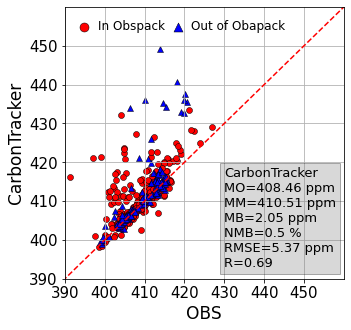

In [29]:
if __name__ =='__main__':
    main('CarbonTracker', obs_data1, model_data1/1000,obs_data2, model_data2/1000,obs_data3, model_data3/1000)